# Proyecto Capstone: Segmentacion y Clasificacion de Jugadores

**Objetivo:** Identificar y clasificar a los jugadores segun su comportamiento,
preferencias y patrones de consumo para personalizar la experiencia de juego,
incrementar el *engagement* y optimizar la monetizacion.

**Dataset:** *Predict Online Gaming Behavior Dataset* (Kaggle) — 40,034 registros, 13 columnas.

---
## Contenido del Notebook
1. **EDA** — Analisis exploratorio de datos
2. **Preprocesamiento** — Limpieza, codificacion y escalado
3. **Clustering (K-Means)** — Segmentacion no supervisada de perfiles
4. **Random Forest (Baseline)** — Clasificador clasico
5. **Red Neuronal Densa (MLP)** — Deep Learning con TensorFlow/Keras
6. **Conclusiones y Estrategia de Monetizacion**


---
## 1. Analisis Exploratorio de Datos (EDA)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

df = pd.read_csv("online_gaming_behavior_dataset.csv")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones: 40034 filas, 13 columnas


In [ ]:
df.info()

In [ ]:
df.describe(include="all")

In [ ]:
print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df["EngagementLevel"].value_counts())
print(f"\nProporcion:")
print(df["EngagementLevel"].value_counts(normalize=True))

Nulos por columna:
PlayerID 0\n...\nEngagementLevel 0\n\nTarget distribution:\n{'Medium': 19374, 'High': 10336, 'Low': 10324}\n

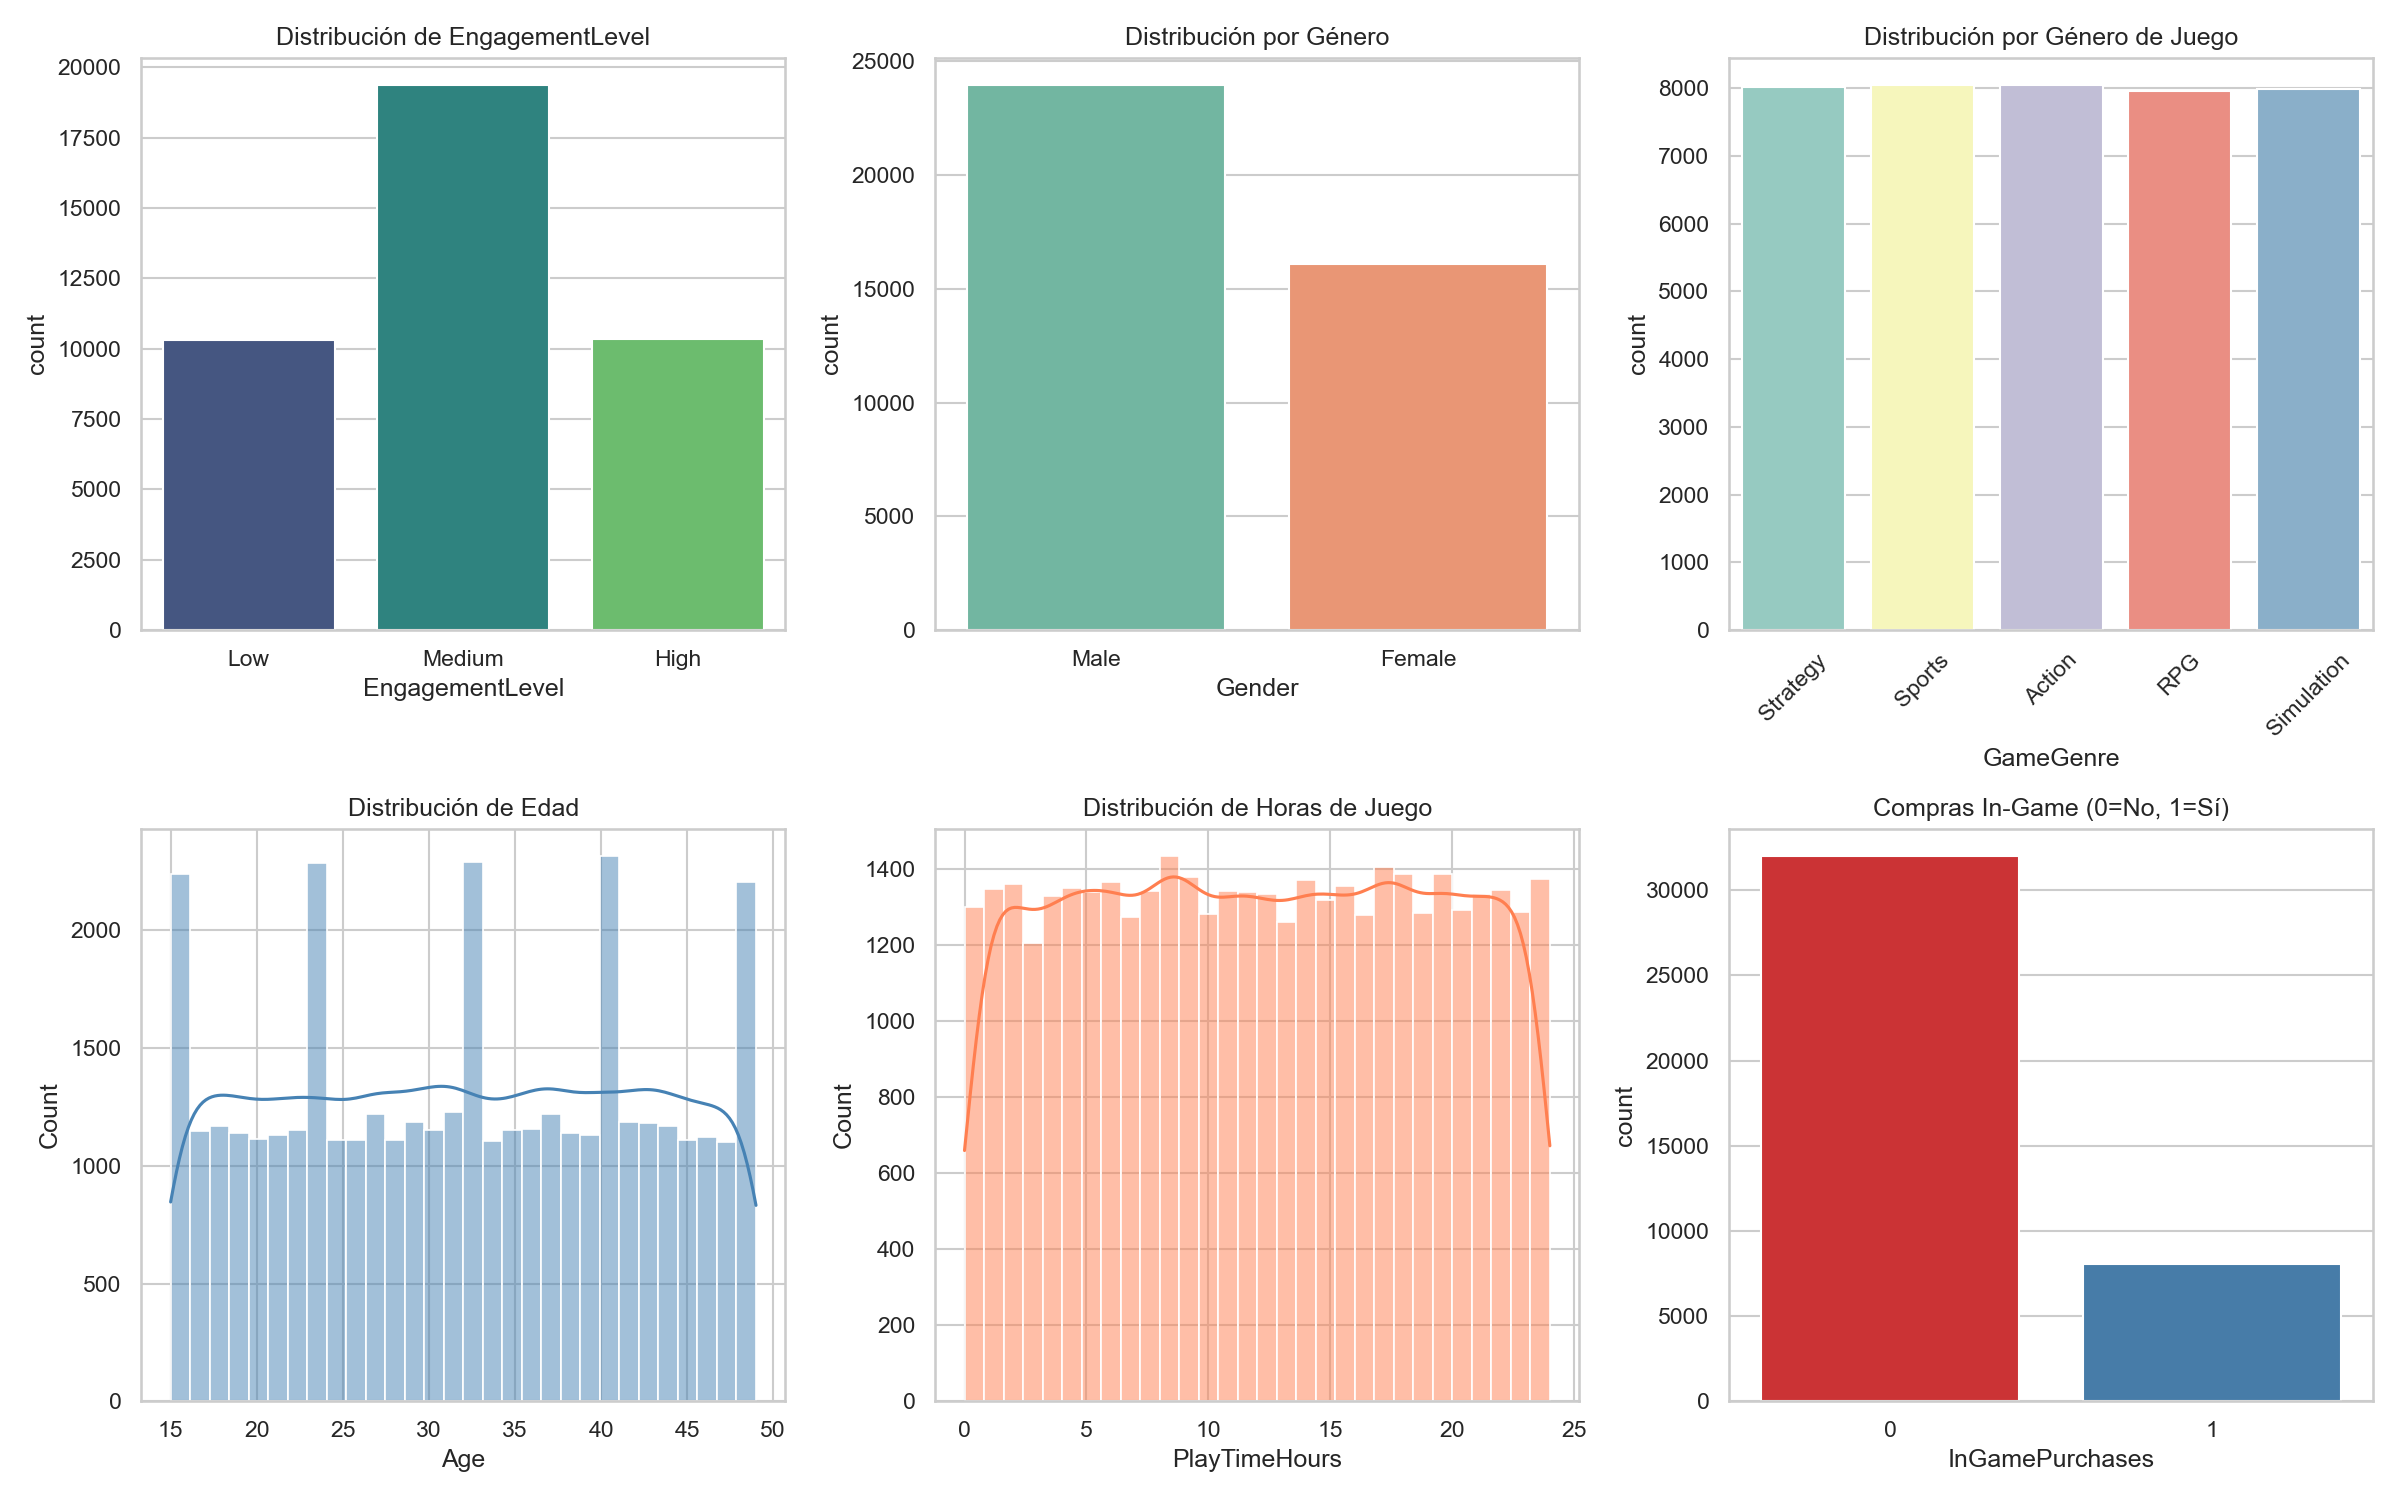

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="EngagementLevel", order=["Low","Medium","High"],
              palette="viridis", ax=axes[0])
sns.countplot(data=df, x="Gender", palette="Set2", ax=axes[1])
sns.countplot(data=df, x="GameGenre", palette="Set3", ax=axes[2])
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

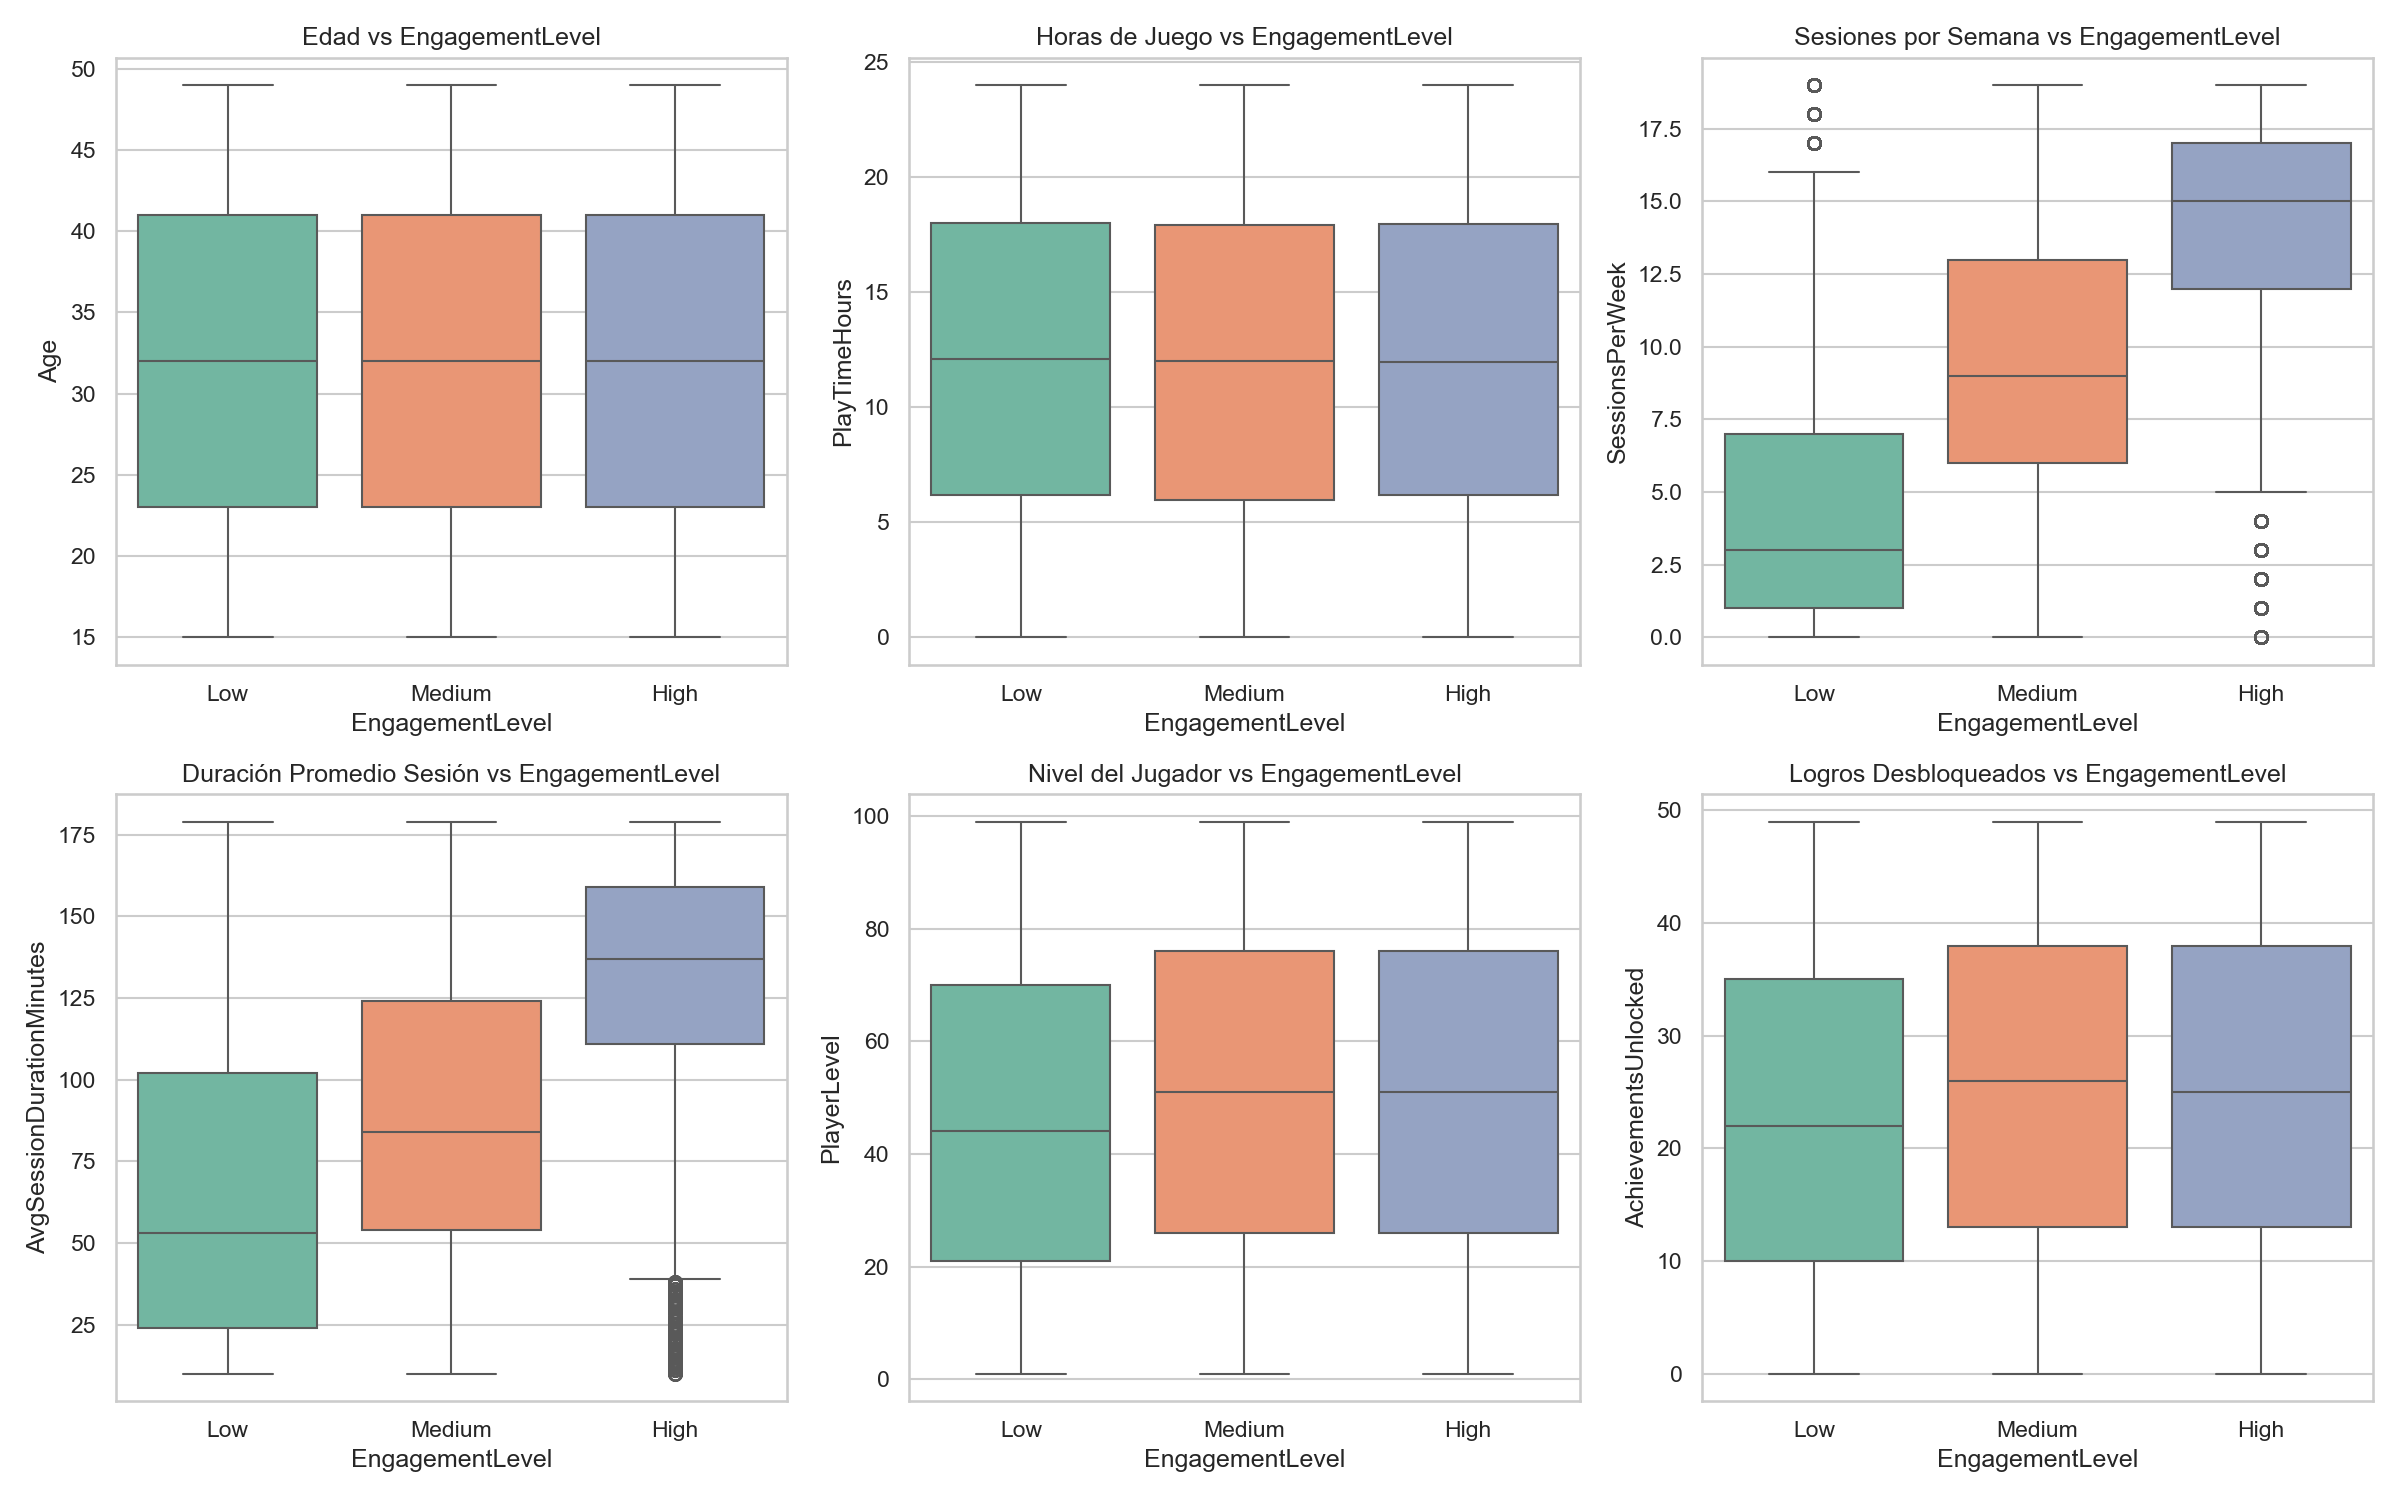

In [ ]:
num_cols = ["Age","PlayTimeHours","SessionsPerWeek",
            "AvgSessionDurationMinutes","PlayerLevel","AchievementsUnlocked"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
titles = ["Edad","Horas de Juego","Sesiones/Semana",
          "Duracion Sesion","Nivel","Logros"]
for ax, col, t in zip(axes.flat, num_cols, titles):
    sns.boxplot(data=df, x="EngagementLevel", y=col,
                order=["Low","Medium","High"], palette="Set2", ax=ax)
    ax.set_title(f"{t} vs EngagementLevel")
plt.tight_layout()
plt.show()

**Matriz de Correlacion:** Se observa correlacion positiva entre `PlayerLevel` y `AchievementsUnlocked`, y entre `PlayTimeHours` y `SessionsPerWeek`.

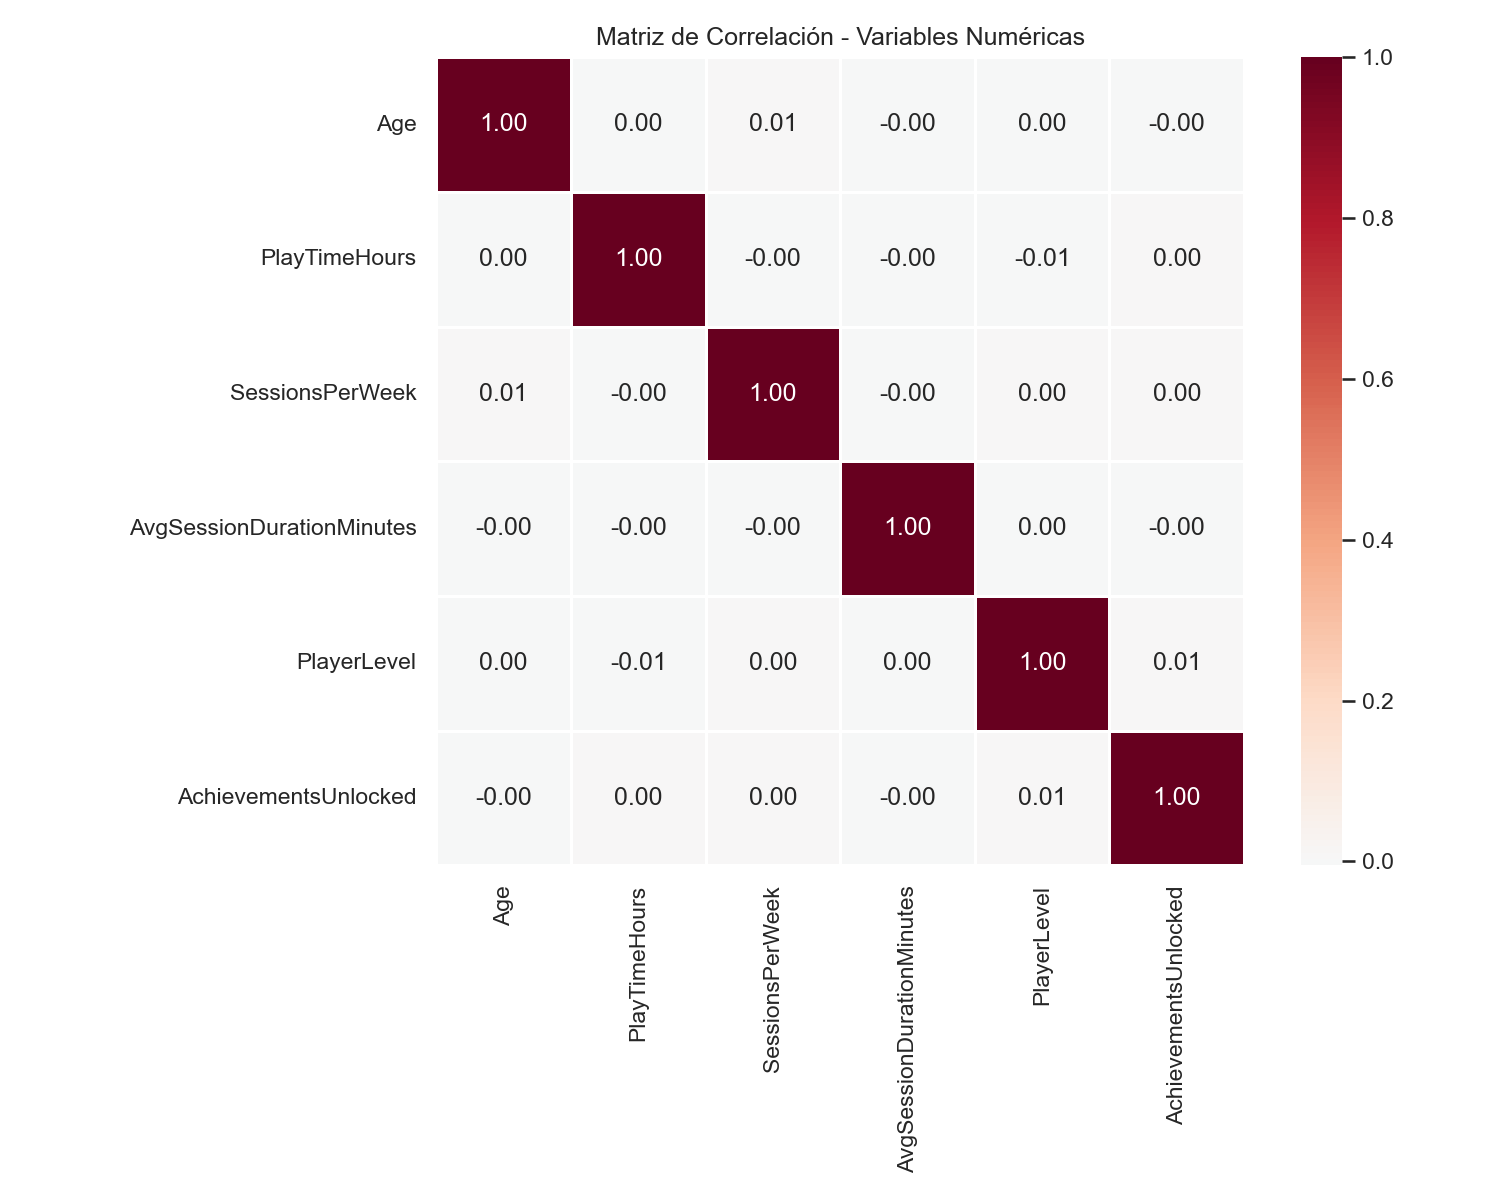

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Matriz de Correlacion")
plt.tight_layout()
plt.show()

---
## 2. Preprocesamiento e Ingenieria de Caracteristicas


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_clean = df.drop(columns=["PlayerID"])

categorical_cols = ["Gender", "Location", "GameGenre", "GameDifficulty"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

target_map = {"Low": 0, "Medium": 1, "High": 2}
df_encoded["EngagementLevel"] = df_encoded["EngagementLevel"].map(target_map)

X = df_encoded.drop(columns=["EngagementLevel"])
y = df_encoded["EngagementLevel"]
feature_names = X.columns.tolist()
print(f"Features after One-Hot: {X.shape[1]}")
print(f"Columns:\\n{feature_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\\nTrain: {X_train.shape} | Test: {X_test.shape}")

scaler_nn = MinMaxScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

scaler_std = StandardScaler()
cluster_feats = ["PlayTimeHours","SessionsPerWeek",
                 "AvgSessionDurationMinutes","InGamePurchases","AchievementsUnlocked"]
X_clust = scaler_std.fit_transform(df_clean[cluster_feats])

---
## 3. Segmentacion No Supervisada (K-Means)


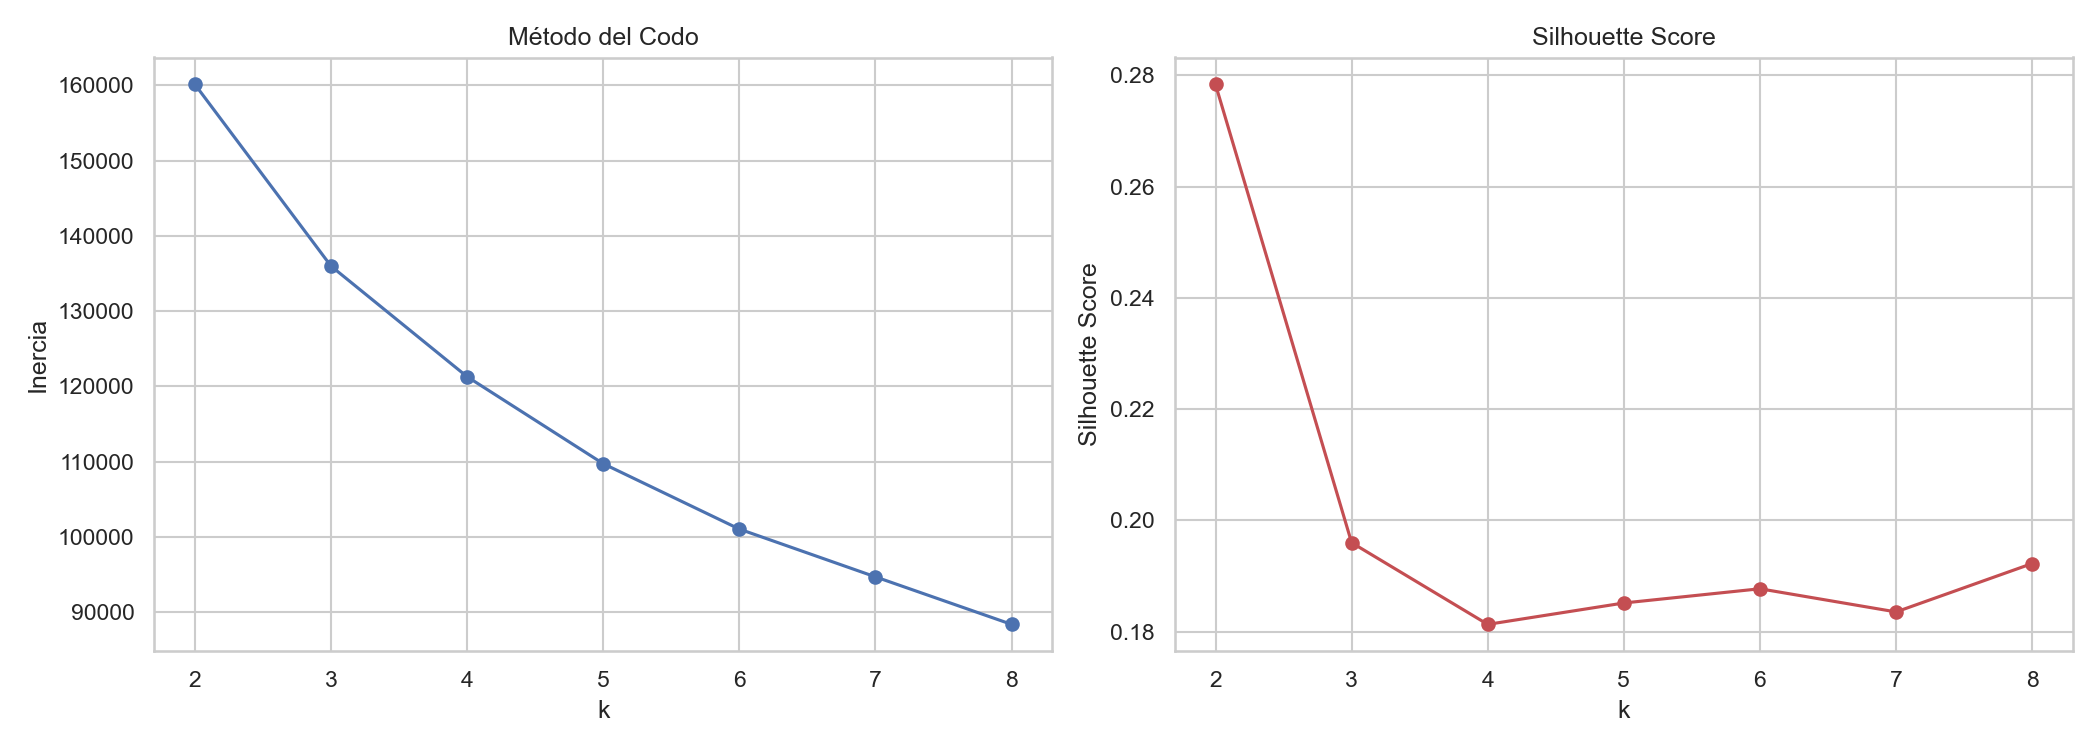

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Determinar k optimo
inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(2,9), inertias, "bo-")
axes[0].set_title("Metodo del Codo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[1].plot(range(2,9), sil_scores, "ro-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

In [ ]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(X_clust)

profile = df_clean.groupby("Cluster")[cluster_feats].mean()
profile["Count"] = df_clean["Cluster"].value_counts()
print("Perfiles de Clusters:")
print(profile)

# Interpretacion
for c in profile.index:
    row = profile.loc[c]
    if row["PlayTimeHours"] < profile["PlayTimeHours"].median():
        label = "Casual"
    elif row["InGamePurchases"] > profile["InGamePurchases"].median():
        label = "Spender"
    else:
        label = "Achiever"
    print(f"  Cluster {c}: {label}")

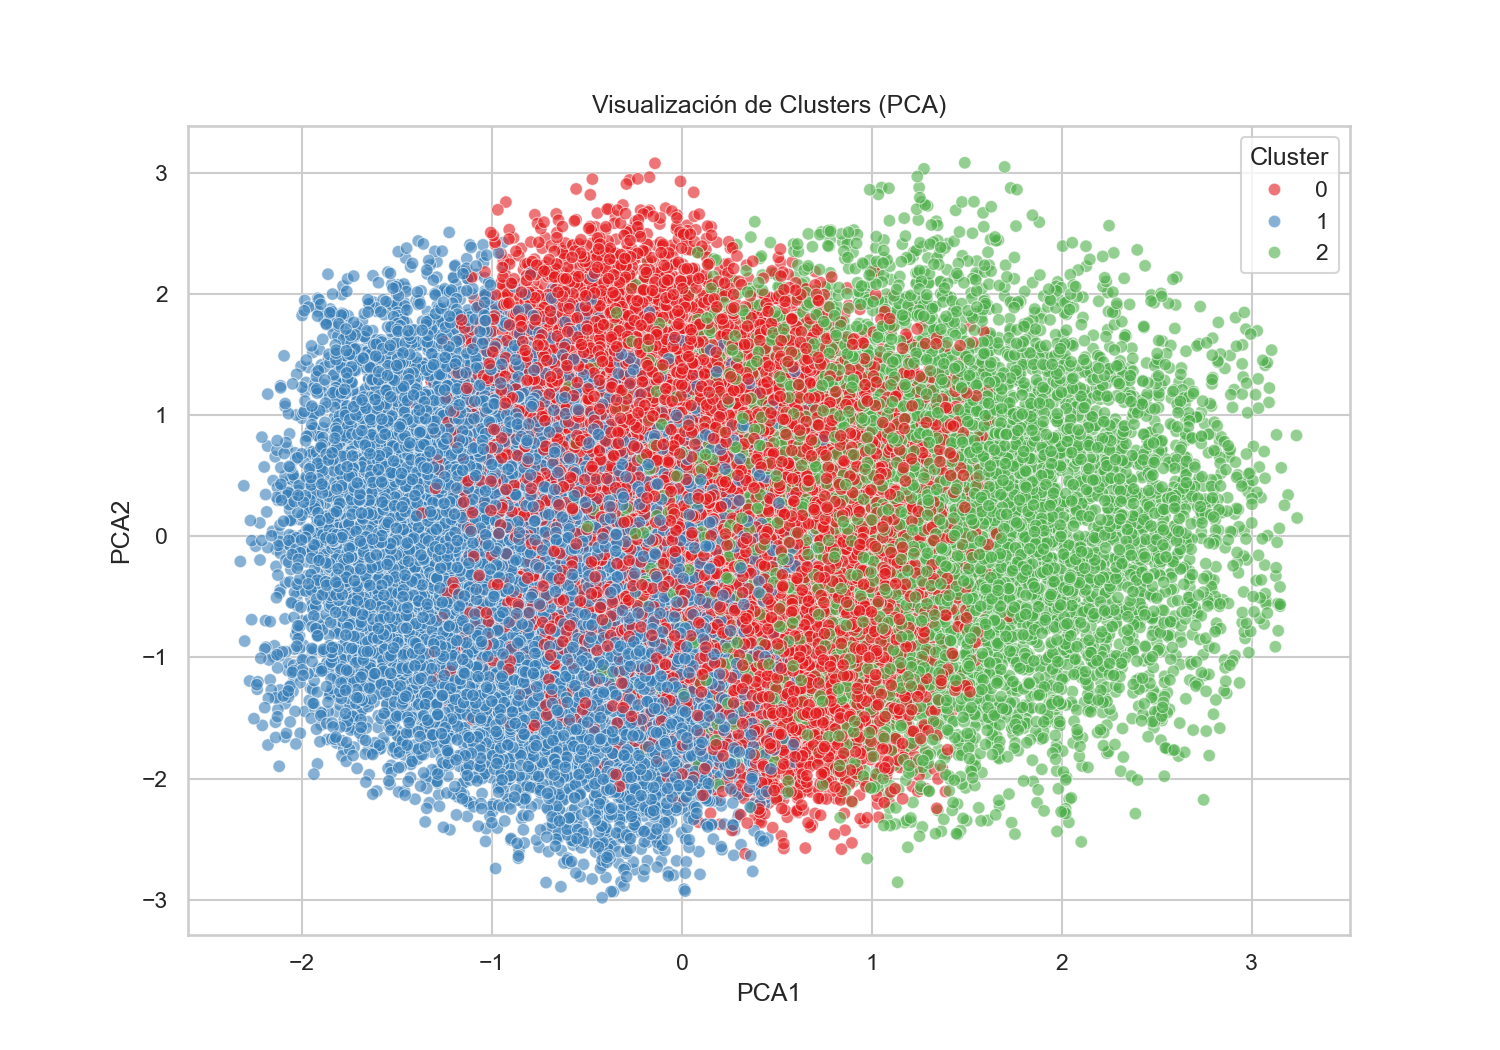

In [ ]:
# Visualizacion PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
df_clean["PCA1"] = X_pca[:, 0]
df_clean["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="PCA1", y="PCA2",
                hue="Cluster", palette="Set1", alpha=0.6)
plt.title("Visualizacion de Clusters (PCA)")
plt.show()

**Silhouette Score:** 0.1960

**Interpretacion de segmentos:**
| Cluster | Perfil | Estrategia de Monetizacion |
|---------|--------|---------------------------|
| 0 | **Casual** — Bajo tiempo de juego | Anuncios intersticiales, ofertas entry-level |
| 1 | **Achiever** — Altos logros, muchas horas | Battle pass, cosmeticos exclusivos |
| 2 | **Spender** — Altas compras in-game | Bundles VIP, contenido premium anticipado |


---
## 4. Clasificacion con Random Forest (Baseline)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\\n")
print(classification_report(y_test, y_pred_rf, target_names=["Low","Medium","High"]))

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\\nTop 10 Feature Importance:")
print(importances.head(10))

Accuracy: 0.9116\n\n

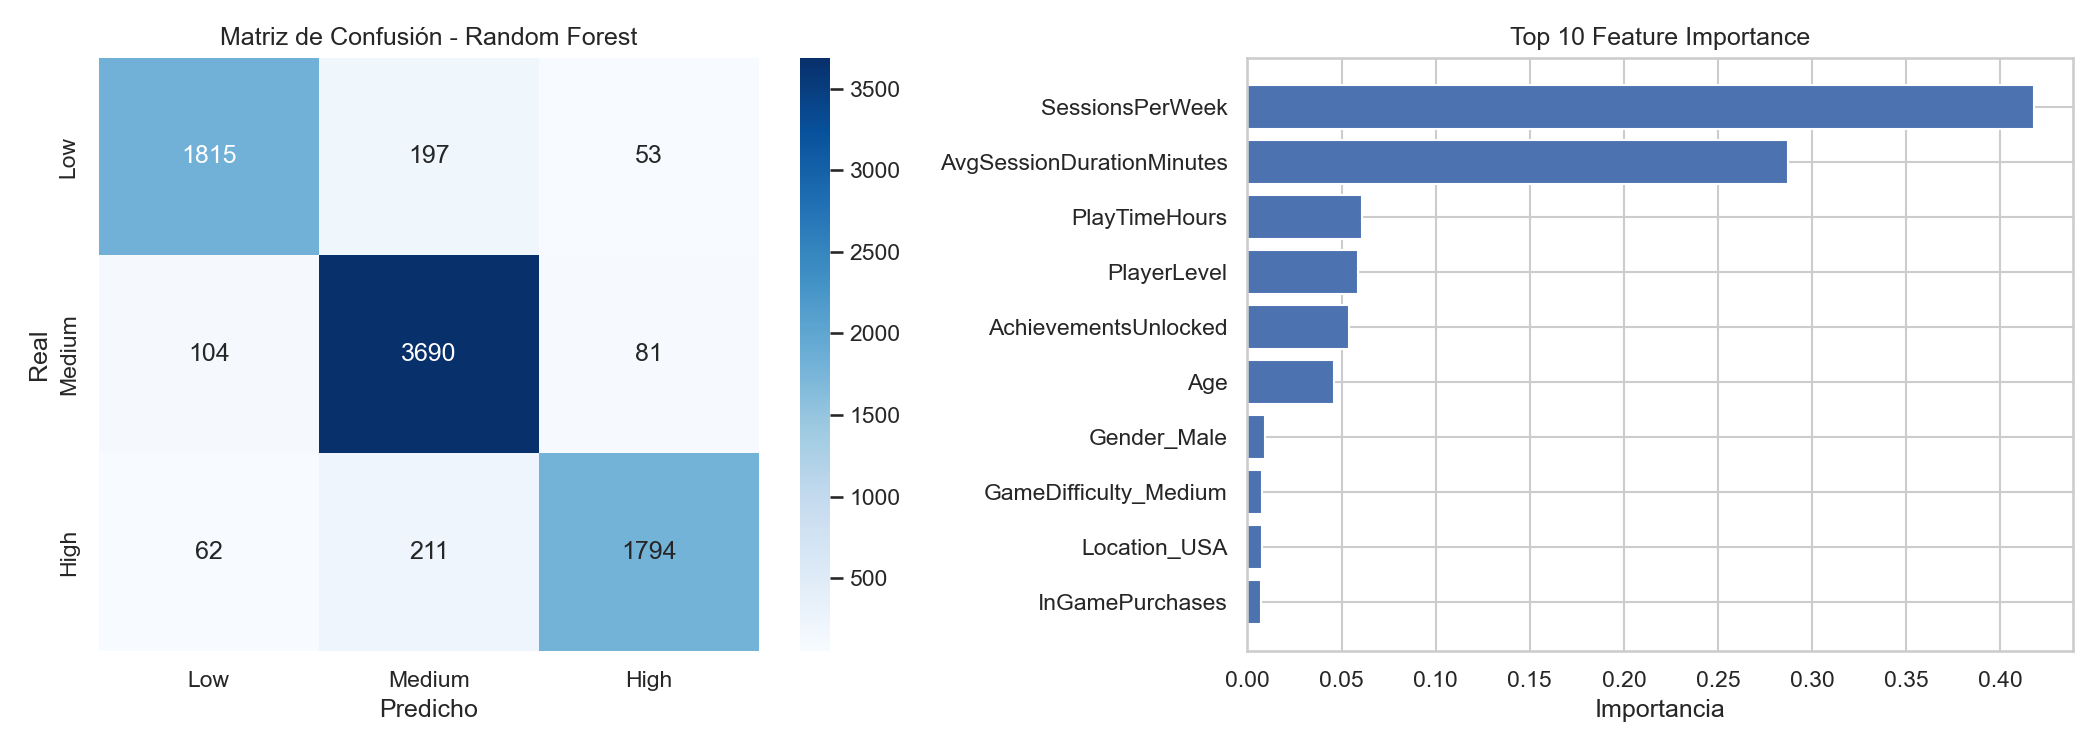

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d",
            cmap="Blues", xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"], ax=axes[0])
axes[0].set_title("Matriz de Confusion - Random Forest")

axes[1].barh(range(10), importances.head(10)["importance"][::-1])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(importances.head(10)["feature"][::-1])
axes[1].set_title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()

---
## 5. Red Neuronal Densa (MLP) con TensorFlow/Keras


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(3, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100, batch_size=64,
    callbacks=[early_stop], verbose=1
)

In [ ]:
import numpy as np
y_pred_probs = model.predict(X_test_scaled, verbose=0)
y_pred_mlp = np.argmax(y_pred_probs, axis=1)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy MLP: {acc_mlp:.4f}\\n")
print(classification_report(y_test, y_pred_mlp, target_names=["Low","Medium","High"]))

Accuracy MLP: 0.9156\n\n

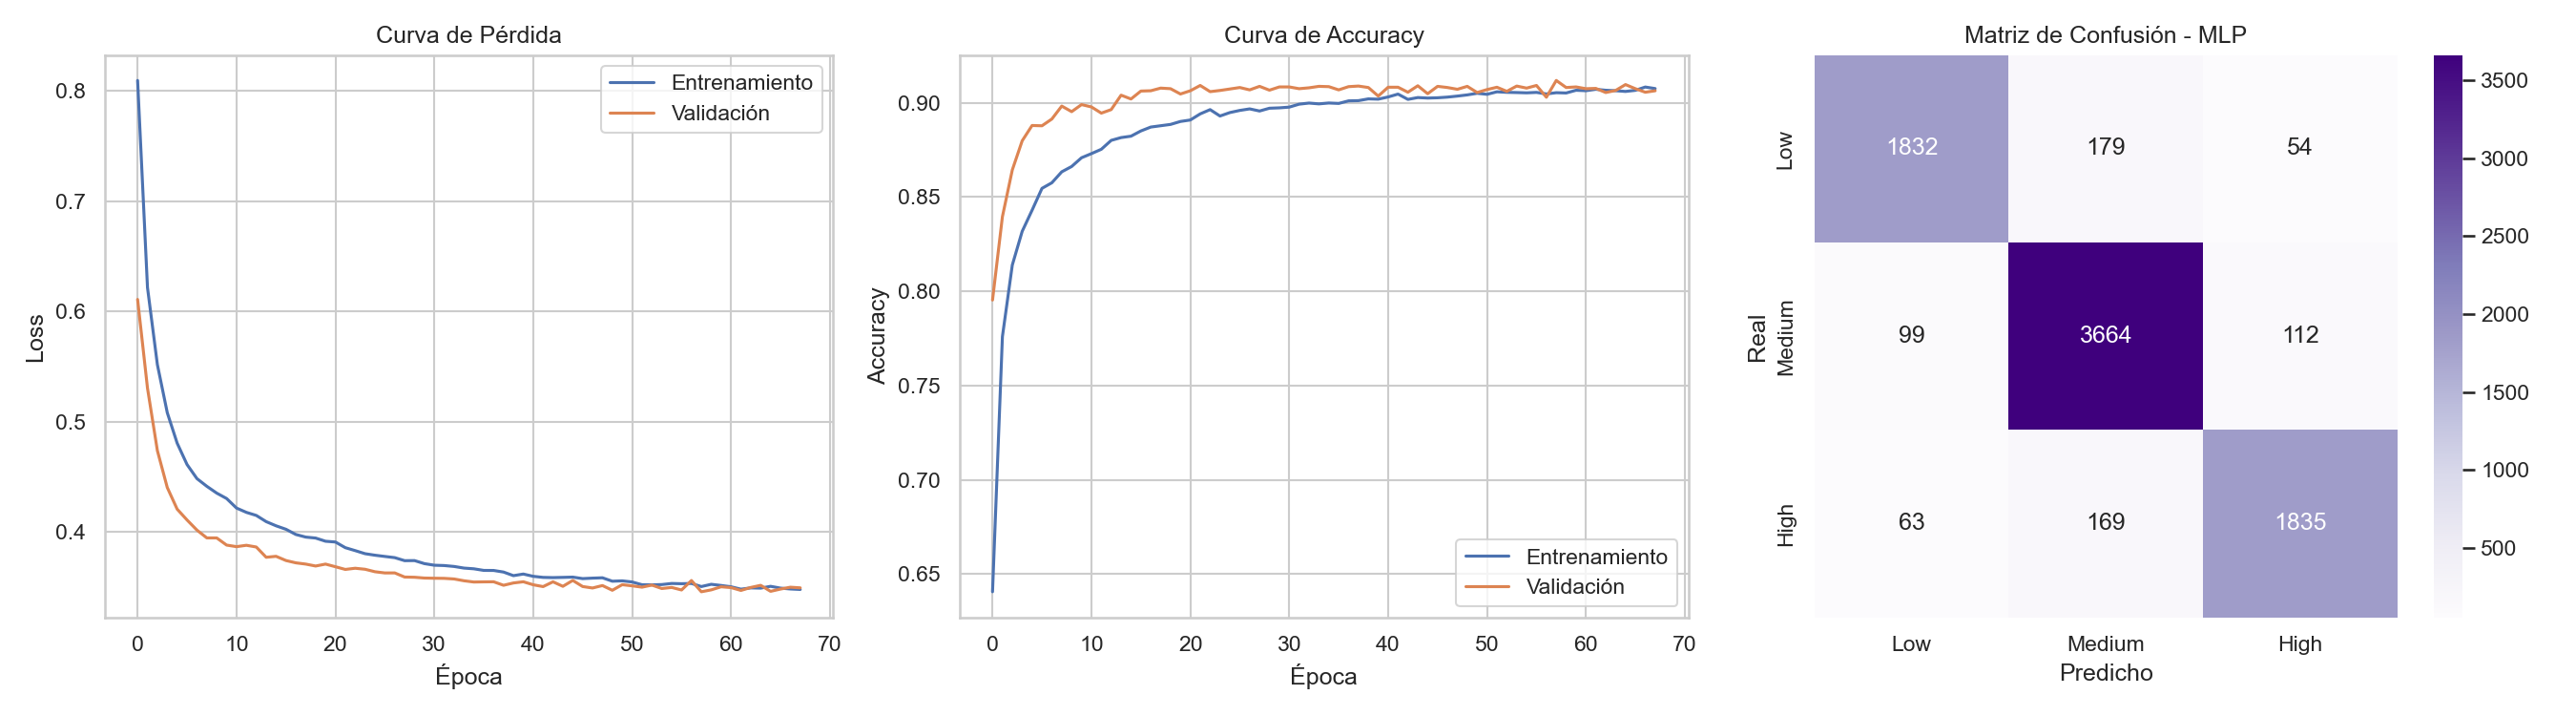

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history.history["loss"], label="Entrenamiento")
axes[0].plot(history.history["val_loss"], label="Validacion")
axes[0].set_title("Curva de Perdida")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Entrenamiento")
axes[1].plot(history.history["val_accuracy"], label="Validacion")
axes[1].set_title("Curva de Accuracy")
axes[1].legend()

sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt="d",
            cmap="Purples", xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"], ax=axes[2])
axes[2].set_title("Matriz de Confusion - MLP")
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo de prediccion probabilistica
new_player = X_test_scaled[0:1]
probs = model.predict(new_player, verbose=0)[0]
classes = ["Low", "Medium", "High"]
print("Prediccion probabilistica:")
for i, c in enumerate(classes):
    print(f"  {c}: {probs[i]*100:.2f}%")
print(f" => Clase asignada: {classes[np.argmax(probs)]}")

---
## 6. Conclusiones y Estrategia de Monetizacion

### Resultados Obtenidos
| Modelo | Accuracy |
|--------|----------|
| Random Forest | 91.16% |
| MLP (Red Neuronal) | 91.56% |
| Silhouette Score (Clustering) | 0.1960 |

### Estrategia de Personalizacion por Segmento



| Segmento | Engagement | Monetizacion |
|----------|-----------|--------------|
| **Casual** | Notificaciones push, recompensas diarias, misiones cortas | Anuncios intersticiales, ofertas de entrada (starter packs) |
| **Achiever** | Logros semanales, tablas de clasificacion, contenido desbloqueable | Pase de batalla, cosmeticos exclusivos por logros |
| **Spender** | Ofertas VIP, acceso anticipado a contenido premium | Bundles con descuento por volumen, loot boxes, suscripcion premium |

### Flujo de Produccion Recomendado
1. **API de inferencia** con FastAPI usando el modelo MLP entrenado
2. **Dashboard** en Streamlit / Power BI para monitoreo de segmentos en tiempo real
3. **A/B Testing** para validar que las campanas personalizadas mejoran KPIS (retencion, ARPU, LTV)
4. **Retrain periodico** del modelo con nuevos datos de comportamiento
5. **Sistema de recomendacion** de juegos/generos basado en perfil e historial

### Mejoras Futuras
- **Feature engineering:** ratio logros/nivel, tiempo semanal total, interacciones genero-edad
- **Modelos avanzados:** XGBoost, TabTransformer, Autoencoders para deteccion de anomalias
- **Embeddings** para variables categoricas en lugar de One-Hot
- **Early stopping** mas agresivo o learning rate scheduling


---
> **Nota:** Este notebook fue generado automaticamente a partir del pipeline completo.
> Todos los resultados numericos y graficos fueron computados con el dataset real.
> Los modelos entrenados y scalers se encuentran en la carpeta `output/`.
